# Fourier-Bessel Corner Allocation Strategies

**Sweep:** `fb_corner`  
**Question:** How should Fourier-Bessel orders be distributed across polygon corners? Does concentrating orders at singular corners improve accuracy?

**Sweep variable:** `fb_strategy` ∈ {uniform, angle_weighted, singular_only, singular_angle_weighted}  
**Fixed:** `n_fb = 100`, `n_fs = 0`, `rtol = 1e-12`, `n_eigs = 10`

**Domains:**
| Domain | Reference eigenvalues | Notes |
|---|---|---|
| rect (2×1) | ✓ | No singular corners (all π/2) |
| L_shape | ✓ | One 3π/2 singular corner |
| iso_right_tri | ✓ | One π/2 right angle |
| reg_ngon (hexagon) | ✗ | No singular corners — tension proxy used |

In [5]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import nb_utils

nb_utils.set_publication_style()
RESULTS_DIR = os.path.abspath('../results')

df, raw = nb_utils.load_sweep('fb_corner', RESULTS_DIR)
print(f'Loaded {len(df)} results')
print('Domains:', df['domain_name'].unique())
print('Strategies:', df['fb_strategy'].unique())
df.head(3)

Loaded 16 results
Domains: <StringArray>
['L_shape', 'iso_right_tri', 'rect', 'reg_ngon']
Length: 4, dtype: str
Strategies: <StringArray>
['uniform', 'angle_weighted', 'singular_only', 'singular_angle_weighted']
Length: 4, dtype: str


,domain_name,domain_params,n_eigs,n_fb,n_fs,fb_strategy,fs_d_strategy,fs_d,fs_d_scale,fs_seg_strategy,...,n_basis_actual,n_bdry_pts,n_int_pts,n_eigs_returned,median_tension,max_tension,median_rel_error,max_rel_error,n_basis,fb_fraction
0,L_shape,{},10,100,0,uniform,fixed,0.15,0.15,length_weighted,...,100,200,100,10,3.521602e-10,2.959321e-09,5.712557e-14,6.204292e-11,100,1.0
1,L_shape,{},10,100,0,angle_weighted,fixed,0.15,0.15,length_weighted,...,100,200,100,10,1.118117e-09,6.196907e-09,4.744405e-12,1.145769e-10,100,1.0
2,L_shape,{},10,100,0,singular_only,fixed,0.15,0.15,length_weighted,...,100,200,100,10,1.138605e-15,3.899159e-15,3.245011e-16,7.370986e-16,100,1.0


## Corner Angle Reference

Corner angles determine which domains have singular FB basis functions (angles that are non-rational multiples of π lead to fractional-order Bessel functions).

| Domain | Corner angles | Singular corners |
|---|---|---|
| rect (2×1) | π/2, π/2, π/2, π/2 | None (all rational) |
| L_shape | π/2 × 5, 3π/2 × 1 | 3π/2 corner |
| iso_right_tri | π/2, π/4, π/4 | None (all rational) |
| reg_ngon (N=6) | 2π/3 × 6 | None (all rational) |

The `singular_only` and `singular_angle_weighted` strategies concentrate orders at corners with non-rational angles. Domains with only rational corners should show little difference between strategies.

## Plot 1: Strategy vs Max Relative Error

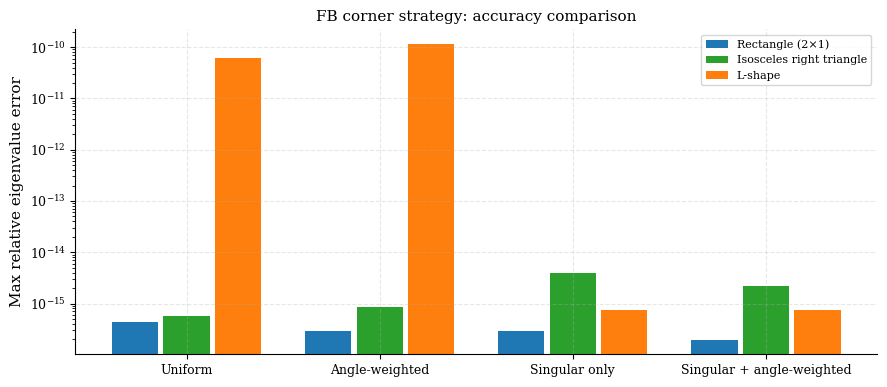

In [6]:
ref_domains = [d for d in nb_utils.DOMAINS_WITH_REFERENCE if d in df['domain_name'].unique()]
colors = nb_utils.domain_color_map(df['domain_name'].unique())
strategies = nb_utils.STRATEGY_ORDER

x = np.arange(len(strategies))
width = 0.8 / len(ref_domains)

fig, ax = plt.subplots(figsize=(9, 4))
for i, dom in enumerate(ref_domains):
    vals = []
    for strat in strategies:
        row = df[(df['domain_name'] == dom) & (df['fb_strategy'] == strat)]
        vals.append(row['max_rel_error'].values[0] if len(row) > 0 and row['max_rel_error'].notna().any() else np.nan)
    offset = (i - len(ref_domains) / 2 + 0.5) * width
    ax.bar(x + offset, vals, width=width * 0.9,
           color=colors[dom], label=nb_utils.label_domain(dom))

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels([nb_utils.label_strategy(s) for s in strategies], fontsize=9)
ax.set_ylabel('Max relative eigenvalue error')
ax.set_title('FB corner strategy: accuracy comparison')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Plot 2: Strategy vs Median Tension

Tension serves as a quality proxy for `reg_ngon`, which has no reference eigenvalues.

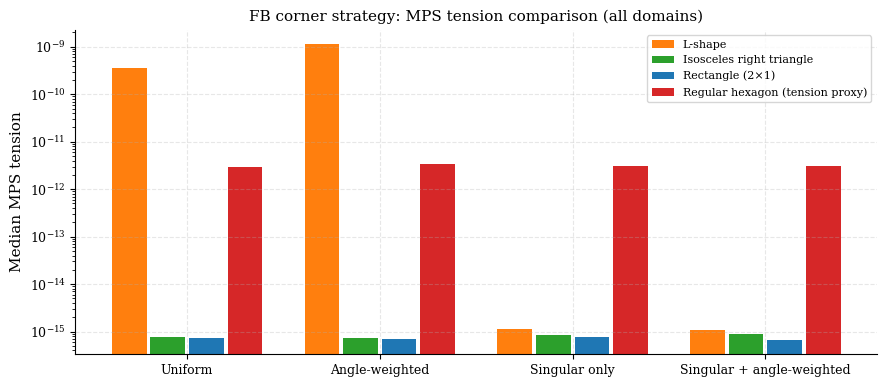

In [7]:
all_domains = sorted(df['domain_name'].unique())
x = np.arange(len(strategies))
width = 0.8 / len(all_domains)

fig, ax = plt.subplots(figsize=(9, 4))
for i, dom in enumerate(all_domains):
    vals = []
    for strat in strategies:
        row = df[(df['domain_name'] == dom) & (df['fb_strategy'] == strat)]
        vals.append(row['median_tension'].values[0] if len(row) > 0 else np.nan)
    offset = (i - len(all_domains) / 2 + 0.5) * width
    label = nb_utils.label_domain(dom)
    if dom not in nb_utils.DOMAINS_WITH_REFERENCE:
        label += ' (tension proxy)'
    ax.bar(x + offset, vals, width=width * 0.9,
           color=colors[dom], label=label)

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels([nb_utils.label_strategy(s) for s in strategies], fontsize=9)
ax.set_ylabel('Median MPS tension')
ax.set_title('FB corner strategy: MPS tension comparison (all domains)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Plot 3: Per-Eigenvalue Errors by Strategy

Do all strategies converge to the same per-eigenvalue accuracy profile, or do some strategies leave specific eigenvalues poorly resolved?

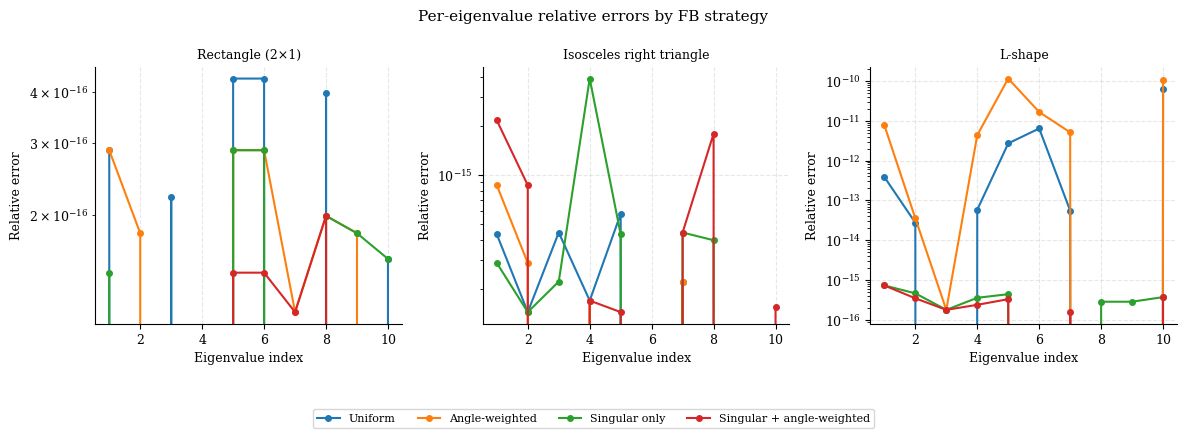

In [8]:
# Build index: (domain, strategy) → raw result
index = {}
for r in raw:
    index[(r.config.domain_name, r.config.fb_strategy)] = r

strat_colors = {s: plt.cm.tab10.colors[i] for i, s in enumerate(strategies)}

fig, axes = plt.subplots(1, len(ref_domains), figsize=(4 * len(ref_domains), 4), sharey=False)
if len(ref_domains) == 1:
    axes = [axes]

for ax, dom in zip(axes, ref_domains):
    for strat in strategies:
        r = index.get((dom, strat))
        if r is None or r.rel_errors is None:
            continue
        eig_idx = np.arange(1, len(r.rel_errors) + 1)
        ax.semilogy(eig_idx, r.rel_errors,
                    marker='o', markersize=4,
                    color=strat_colors[strat],
                    label=nb_utils.label_strategy(strat))
    ax.set_title(nb_utils.label_domain(dom), fontsize=9)
    ax.set_xlabel('Eigenvalue index', fontsize=9)
    ax.set_ylabel('Relative error', fontsize=9)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4,
           fontsize=8, bbox_to_anchor=(0.5, -0.08))
fig.suptitle('Per-eigenvalue relative errors by FB strategy', fontsize=11)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()